In [11]:
import pandas as pd
import numpy as np

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob

from sklearn.feature_extraction.text import CountVectorizer

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [12]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
from google.colab import files
uploaded = files.upload()

Saving Tweets.csv to Tweets (1).csv


In [18]:
df = pd.read_csv("/content/Tweets.csv")

In [20]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [21]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned"] = df["text"].apply(clean_text)

print(df.head())

             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1                    NaN    jnar

In [22]:
def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned"].apply(get_sentiment)

print(df.head())

             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1                    NaN    jnar

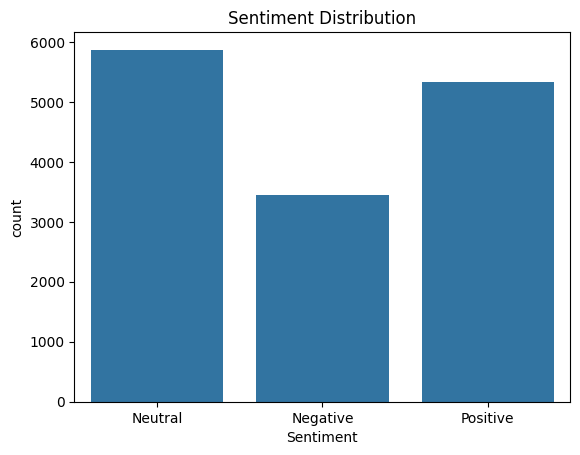

In [23]:
sns.countplot(x="Sentiment", data=df)

plt.title("Sentiment Distribution")

plt.show()

In [24]:
vectorizer = CountVectorizer(max_features=20)

X = vectorizer.fit_transform(df["Cleaned"])

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

freq = pd.DataFrame({
    "Word": words,
    "Count": counts
})

freq = freq.sort_values(by="Count", ascending=False)

print(freq)

         Word  Count
5      flight   4519
6         get   1370
9        hour   1133
18     thanks   1072
2   cancelled   1056
15    service    987
19       time    942
4    customer    930
7        help    861
1         bag    757
10         im    741
13      plane    717
8        hold    639
0         amp    638
11       need    631
17      thank    602
12        one    577
3        cant    573
16      still    571
14     please    560


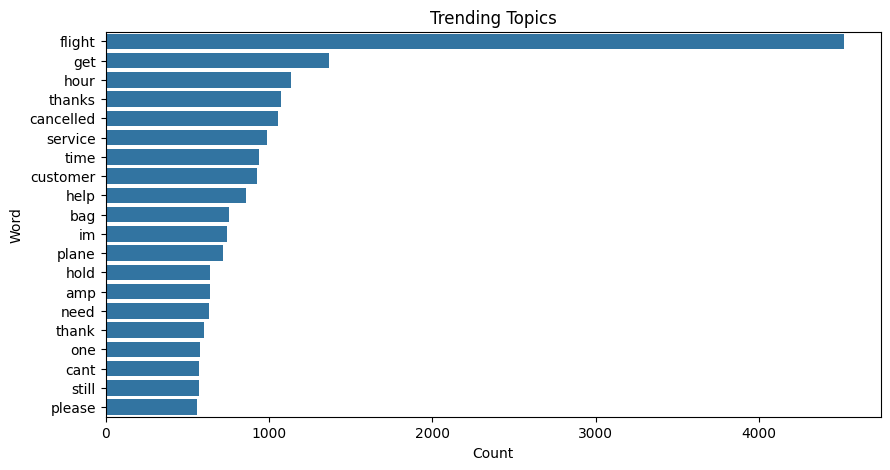

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(x="Count", y="Word", data=freq)

plt.title("Trending Topics")

plt.show()

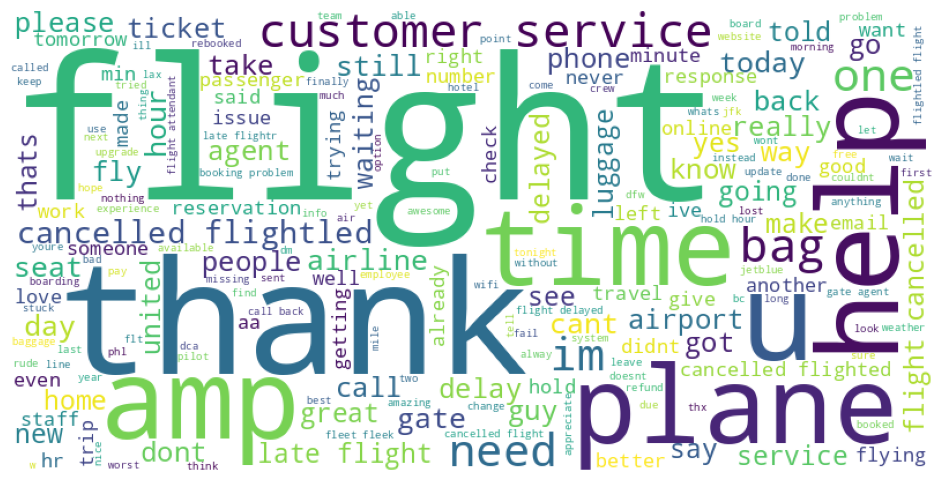

In [26]:
text = " ".join(df["Cleaned"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

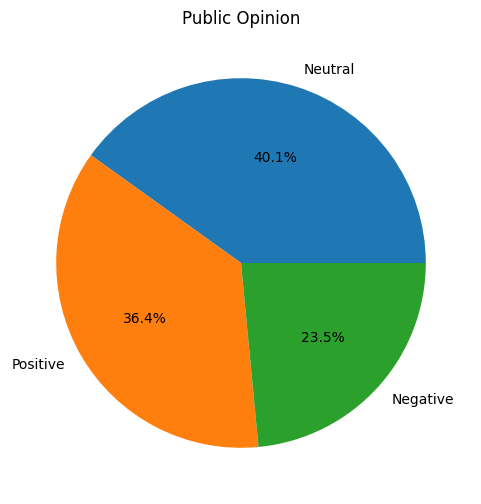

In [27]:
df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Public Opinion")

plt.ylabel("")

plt.show()